# <font color='blue'>Implement SGD Classifier with Logloss and L2 regularization without using sklearn</font>

**There will be some functions that start with the word "grader" ex: grader_weights(), grader_sigmoid(), grader_logloss() etc,should not change those function definition.<br><br>Every Grader function has to return True.**

<font color='red'> Importing packages</font>

In [ ]:
import numpy as np
#import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import linear_model

<font color='red'>Creating custom dataset</font>

In [ ]:
# please don't change random_state
X, y = make_classification(n_samples=50000, n_features=15, n_informative=10, n_redundant=5,
                           n_classes=2, weights=[0.7], class_sep=0.7, random_state=15)
# make_classification is used to create custom dataset
# Please check this link (https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_classification.html) for more details

In [ ]:
X.shape, y.shape

((50000, 15), (50000,))

<font color='red'>Splitting data into train and test </font>

In [ ]:
#please don't change random state
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

In [ ]:
# Standardizing the data.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((37500, 15), (37500,), (12500, 15), (12500,))

# <font color='red' size=5>SGD classifier</font>

In [ ]:
# alpha : float
# Constant that multiplies the regularization term.

# eta0 : double ;Learning Rate: Used to limit the amount each coefficient is corrected each time it is updated.
# The initial learning rate for the ‘constant’, ‘invscaling’ or ‘adaptive’ schedules.

clf = linear_model.SGDClassifier(eta0=0.0001, alpha=0.0001, loss='log', random_state=15, penalty='l2', tol=1e-3, verbose=2, learning_rate='constant')
clf
# Please check this documentation (https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html)

SGDClassifier(alpha=0.0001, average=False, class_weight=None,
              early_stopping=False, epsilon=0.1, eta0=0.0001,
              fit_intercept=True, l1_ratio=0.15, learning_rate='constant',
              loss='log', max_iter=1000, n_iter_no_change=5, n_jobs=None,
              penalty='l2', power_t=0.5, random_state=15, shuffle=True,
              tol=0.001, validation_fraction=0.1, verbose=2, warm_start=False)

In [ ]:
clf.fit(X=X_train, y=y_train) # fitting our model

-- Epoch 1
Norm: 0.70, NNZs: 15, Bias: -0.501317, T: 37500, Avg. loss: 0.552526
Total training time: 0.01 seconds.
-- Epoch 2
Norm: 1.04, NNZs: 15, Bias: -0.752393, T: 75000, Avg. loss: 0.448021
Total training time: 0.02 seconds.
-- Epoch 3
Norm: 1.26, NNZs: 15, Bias: -0.902742, T: 112500, Avg. loss: 0.415724
Total training time: 0.03 seconds.
-- Epoch 4
Norm: 1.43, NNZs: 15, Bias: -1.003816, T: 150000, Avg. loss: 0.400895
Total training time: 0.04 seconds.
-- Epoch 5
Norm: 1.55, NNZs: 15, Bias: -1.076296, T: 187500, Avg. loss: 0.392879
Total training time: 0.05 seconds.
-- Epoch 6
Norm: 1.65, NNZs: 15, Bias: -1.131077, T: 225000, Avg. loss: 0.388094
Total training time: 0.06 seconds.
-- Epoch 7
Norm: 1.73, NNZs: 15, Bias: -1.171791, T: 262500, Avg. loss: 0.385077
Total training time: 0.07 seconds.
-- Epoch 8
Norm: 1.80, NNZs: 15, Bias: -1.203840, T: 300000, Avg. loss: 0.383074
Total training time: 0.08 seconds.
-- Epoch 9
Norm: 1.86, NNZs: 15, Bias: -1.229563, T: 337500, Avg. loss: 0.

SGDClassifier(alpha=0.0001, average=False, class_weight=None,
              early_stopping=False, epsilon=0.1, eta0=0.0001,
              fit_intercept=True, l1_ratio=0.15, learning_rate='constant',
              loss='log', max_iter=1000, n_iter_no_change=5, n_jobs=None,
              penalty='l2', power_t=0.5, random_state=15, shuffle=True,
              tol=0.001, validation_fraction=0.1, verbose=2, warm_start=False)

In [ ]:
clf.coef_, clf.coef_.shape, clf.intercept_
#clf.coef_ will return the weights
#clf.coef_.shape will return the shape of weights
#clf.intercept_ will return the intercept term

(array([[-0.89007184,  0.63162363, -0.07594145,  0.63107107, -0.38434375,
          0.93235243, -0.89573521, -0.07340522,  0.40591417,  0.4199991 ,
          0.24722143,  0.05046199, -0.08877987,  0.54081652,  0.06643888]]),
 (1, 15),
 array([-1.30580538]))



## <font color='blue' size=5> Implement Logistic Regression with L2 regularization Using SGD: without using sklearn </font>




<br>

* Initialize the weight_vector and intercept term to zeros (code in <font color='blue'>def initialize_weights()</font>)

* Create a loss function (code in <font color='blue'>def logloss()</font>)

 $log loss = -1*\frac{1}{n}\Sigma_{for each Yt,Y_{pred}}(Ytlog10(Y_{pred})+(1-Yt)log10(1-Y_{pred}))$
- for each epoch:

    - for each batch of data points in train: (keep batch size=1)

        - calculate the gradient of loss function w.r.t each weight in weight vector (write your code in <font color='blue'>def gradient_dw()</font>)

        $dw^{(t)} = x_n(y_n − σ((w^{(t)})^{T} x_n+b^{t}))- \frac{λ}{N}w^{(t)})$ <br>

        - Calculate the gradient of the intercept (write your code in <font color='blue'> def gradient_db()</font>) <a href='https://drive.google.com/file/d/1nQ08-XY4zvOLzRX-lGf8EYB5arb7-m1H/view?usp=sharing'>check this</a>

           $ db^{(t)} = y_n- σ((w^{(t)})^{T} x_n+b^{t}))$

        - Update weights and intercept (check the equation number 32 in the above mentioned <a href='https://drive.google.com/file/d/1nQ08-XY4zvOLzRX-lGf8EYB5arb7-m1H/view?usp=sharing'>pdf</a>): <br>
        $w^{(t+1)}← w^{(t)}+α(dw^{(t)}) $<br>

        $b^{(t+1)}←b^{(t)}+α(db^{(t)}) $
    - calculate the log loss for train and test with the updated weights.
    - Can compare the previous loss and the current loss, if it is not updating, then stop the training
    - append this loss in the list ( this will be used to see how loss is changing for each epoch after the training is over )


<font color='blue'>Initialize weights </font>

In [ ]:
def initialize_weights(dim):
    ''' In this function, we will initialize our weights and bias'''
    #initialize the weights to zeros array of (1,dim) dimensions
    #you use zeros_like function to initialize zero, check this link https://docs.scipy.org/doc/numpy/reference/generated/numpy.zeros_like.html
    #initialize bias to zero
    w = np.zeros_like(X_train[0])  # elements in w = no of features
    b = 0
    return w,b

In [ ]:
dim=X_train[0]
w,b = initialize_weights(dim)
print('w =',(w))
print('b =',str(b))

w = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
b = 0


<font color='cyan'>Grader function - 1 </font>

In [ ]:
dim=X_train[0]
w,b = initialize_weights(dim)
def grader_weights(w,b):
  assert((len(w)==len(dim)) and b==0 and np.sum(w)==0.0)#assert keyword is used when debugging code.Allows to test if a condition in code returns True, if not, the program will raise an AssertionError.
  return True
grader_weights(w,b)

True

<font color='blue'>Compute sigmoid </font>

$sigmoid(z)= 1/(1+exp(-z))$

In [ ]:
def sigmoid(z):
    ''' In this function, we will return sigmoid of z'''
    # compute sigmoid(z) and return
    sigma = 1/ (1+np.exp(-z))
    return sigma

<font color='cyan'>Grader function - 2</font>

In [ ]:
def grader_sigmoid(z):
  val=sigmoid(z)
  assert(val==0.8807970779778823)
  return True
grader_sigmoid(2)

True

<font color='blue'> Compute loss </font>

$log loss = -1*\frac{1}{n}\Sigma_{for each Yt,Y_{pred}}(Ytlog10(Y_{pred})+(1-Yt)log10(1-Y_{pred}))$

In [ ]:
def logloss(y_true,y_pred):
    '''In this function, we will compute log loss '''
    loss=0
    n=len(y_true)
    Combination = list(zip(y_true, y_pred))
    for Yt, Ypred in Combination:
        loss += (-1/n)*(Yt*np.log10(Ypred) + (1-Yt) * np.log10(1-Ypred))

    return loss

<font color='cyan'>Grader function - 3 </font>

In [ ]:
def grader_logloss(true,pred):
  loss=logloss(true,pred)
  assert(loss==0.07644900402910389)
  return True
true=[1,1,0,1,0]
pred=[0.9,0.8,0.1,0.8,0.2]
grader_logloss(true,pred)

True

<font color='blue'>Compute gradient w.r.to  'w' </font>

$dw^{(t)} = x_n(y_n − σ((w^{(t)})^{T} x_n+b^{t}))- \frac{λ}{N}w^{(t)}$ <br>

In [ ]:
def gradient_dw(x,y,w,b,alpha,N):
    '''In this function, we will compute the gardient w.r.to w '''
    dw = x * (y - sigmoid(np.dot(w, x) + b) - (alpha / N) * w)

    return dw

<font color='cyan'>Grader function - 4 </font>

In [ ]:
def grader_dw(x,y,w,b,alpha,N):
  grad_dw=gradient_dw(x,y,w,b,alpha,N)
  assert(np.sum(grad_dw)==2.613689585)
  return True
grad_x=np.array([-2.07864835,  3.31604252, -0.79104357, -3.87045546, -1.14783286,
       -2.81434437, -0.86771071, -0.04073287,  0.84827878,  1.99451725,
        3.67152472,  0.01451875,  2.01062888,  0.07373904, -5.54586092])
grad_y=0
grad_w,grad_b=initialize_weights(grad_x)
alpha=0.0001
N=len(X_train)
grader_dw(grad_x,grad_y,grad_w,grad_b,alpha,N)

True

<font color='blue'>Compute gradient w.r.to 'b' </font>

$ db^{(t)} = y_n- σ((w^{(t)})^{T} x_n+b^{t})$

In [ ]:
 def gradient_db(x,y,w,b):
        '''In this function, we will compute gradient w.r.to b '''
        db =y - sigmoid((np.dot(w,x) + b))
        return db

<font color='cyan'>Grader function - 5 </font>

In [ ]:
def grader_db(x,y,w,b):
  grad_db=gradient_db(x,y,w,b)
  assert(grad_db==-0.5)
  return True
grad_x=np.array([-2.07864835,  3.31604252, -0.79104357, -3.87045546, -1.14783286,
       -2.81434437, -0.86771071, -0.04073287,  0.84827878,  1.99451725,
        3.67152472,  0.01451875,  2.01062888,  0.07373904, -5.54586092])
grad_y=0
grad_w,grad_b=initialize_weights(grad_x)
alpha=0.0001
N=len(X_train)
grader_db(grad_x,grad_y,grad_w,grad_b)

True

<font color='blue'> Implementing logistic regression</font>

In [ ]:
def train(X_train,y_train,X_test,y_test,epochs,alpha,eta0):
    ''' In this function, we will implement logistic regression'''
    #Here eta0 is learning rate
    #implement the code as follows
    # initalize the weights (call the initialize_weights(X_train[0]) function)
    # for every epoch
        # for every data point(X_train,y_train)
           #compute gradient w.r.to w (call the gradient_dw() function)
           #compute gradient w.r.to b (call the gradient_db() function)
           #update w, b
        # predict the output of x_train[for all data points in X_train] using w,b
        #compute the loss between predicted and actual values (call the loss function)
        # store all the train loss values in a list
        # predict the output of x_test[for all data points in X_test] using w,b
        #compute the loss between predicted and actual values (call the loss function)
        # store all the test loss values in a list
        # you can also compare previous loss and current loss, if loss is not updating then stop the process and return w,b

    return w,b

In [ ]:
def train(X_train, y_train, X_test, y_test, epochs, alpha, eta0):
    w, b = initialize_weights(X_train[0])  # call initialize weights function

    train_loss = 0
    test_loss = 0
    train_loss_list = []
    test_loss_list = []
    N = X_train.shape[0]
    no_update_count = 0
    for epoch in range(1, epochs + 1):  # this for loop will iterate for the given number of epochs
        test_pred = []
        train_pred = []
        for i in range(len(X_train)): # for every data point(X_train,y_train),this loop will give w & b and update the value of w and b with each iteration

            x = X_train[i]
            y = y_train[i]
            # call the gradient_dw & gradient_db functions
            dw = gradient_dw(x, y, w, b, alpha, N)
            db = gradient_db(x, y, w, b)
            # update w & b
            w = w + (eta0 * dw)
            b = b + (eta0 * db)

        for j in range(len(X_train)): # this loop will give prediction on train set
            xq = X_train[j]
            yq = sigmoid(np.dot(w, xq) + b) # predict o/p for all the datapoints in x_train using sigmoid
            train_pred.append(yq)
        prev_train_loss = train_loss
        train_loss = logloss(y_train,train_pred) # call log loss function to compute loss between predicted & actual values forall data points in train set
        train_loss_list.append(train_loss) # store all train loss values in a list

        for k in range(len(X_test)):  # this loop will giver prediction on test set
            xq = X_test[k]
            yq = sigmoid(np.dot(w, xq) + b)  # predict o/p for all the datapoints in x_test using sigmoid
            test_pred.append(yq)
        prev_test_loss = test_loss
        test_loss = logloss(y_test, test_pred)  # logloss calculation for test set
        test_loss_list.append(test_loss) # store all test loss values in a list

        print('Epoch = {} '.format(epoch), 'Train Loss = {} '.format(train_loss), 'Test Loss = {}'.format(test_loss))

        if abs(test_loss-prev_test_loss) < 1e-4:
            print(100*"-")
            print("At epoch {} we get difference of previous TEST loss and recent TEST loss is less than 1e-4".format(epoch))
            return w,b,train_loss_list,test_loss_list,epoch

        elif abs(train_loss-prev_train_loss) < 1e-4:
            print(100*"-")
            print("At epoch {} we get difference of previous TRAIN loss and recent TRAIN loss is less than 1e-4".format(epoch))
            return w,b,train_loss_list,test_loss_list,epoch
    return w, b, train_loss_list, test_loss_list, epoch

In [ ]:
alpha=0.0001
eta0=0.0001
N=len(X_train)
epochs=15
w,b,trainloss,testloss,epoch=train(X_train,y_train,X_test,y_test,epochs,alpha,eta0)

Epoch = 1  Train Loss = 0.20729781768555627  Test Loss = 0.20722219765639854
Epoch = 2  Train Loss = 0.18556210114210886  Test Loss = 0.1856525940776223
Epoch = 3  Train Loss = 0.176596520511334  Test Loss = 0.17682567687044431
Epoch = 4  Train Loss = 0.1720128945783096  Test Loss = 0.17235324810702052
Epoch = 5  Train Loss = 0.16938000845565118  Test Loss = 0.16981009801866537
Epoch = 6  Train Loss = 0.1677533653450306  Test Loss = 0.16825663459379245
Epoch = 7  Train Loss = 0.1666977625731437  Test Loss = 0.16726128852995362
Epoch = 8  Train Loss = 0.16598837461497812  Test Loss = 0.16660192950797534
Epoch = 9  Train Loss = 0.16549918190509527  Test Loss = 0.166154570882179
Epoch = 10  Train Loss = 0.16515513910536153  Test Loss = 0.165845726384316
Epoch = 11  Train Loss = 0.16490944263438437  Test Loss = 0.16562980512109748
Epoch = 12  Train Loss = 0.16473183083664983  Test Loss = 0.16547750011239468
Epoch = 13  Train Loss = 0.16460216936736327  Test Loss = 0.16536943657077618
Epoch

<font color='red'>Goal of assignment</font>

Compare your implementation and SGDClassifier's the weights and intercept, make sure they are as close as possible i.e difference should be in terms of 10^-3

In [ ]:
# these are the results we got after we implemented sgd and found the optimal weights and intercept
w-clf.coef_, b-clf.intercept_

(array([[-4.75142659e-03,  7.60248362e-03,  1.85101563e-03,
          6.50616171e-05,  1.54496319e-03,  2.34090261e-03,
         -9.09959192e-04,  2.16124271e-03,  5.21961272e-03,
         -4.49832519e-03,  1.23629737e-03,  2.54417911e-03,
          1.74962265e-03, -1.28754200e-03,  1.05365292e-03]]),
 array([0.0027995]))

In [ ]:
print("w:",w)#manually computed weights
print("clf.coef:", clf.coef_)#clf.coef_ will return the sklearn weights
print("w-clf.coef_",w-clf.coef_)# difference of manually computed and sklearn weights

print("b:",b)#manually computed intercept
print("clf.intercept_:",clf.intercept_)#clf.intercept_ will return sklearn intercept term
print("b-clf.intercept_:",b-clf.intercept_)# difference of manually computed and sklearn intercept

w: [-0.89482326  0.63922611 -0.07409043  0.63113614 -0.38279879  0.93469334
 -0.89664517 -0.07124397  0.41113378  0.41550078  0.24845773  0.05300617
 -0.08703024  0.53952898  0.06749254]
clf.coef: [[-0.89007184  0.63162363 -0.07594145  0.63107107 -0.38434375  0.93235243
  -0.89573521 -0.07340522  0.40591417  0.4199991   0.24722143  0.05046199
  -0.08877987  0.54081652  0.06643888]]
w-clf.coef_ [[-4.75142659e-03  7.60248362e-03  1.85101563e-03  6.50616171e-05
   1.54496319e-03  2.34090261e-03 -9.09959192e-04  2.16124271e-03
   5.21961272e-03 -4.49832519e-03  1.23629737e-03  2.54417911e-03
   1.74962265e-03 -1.28754200e-03  1.05365292e-03]]
b: -1.3030058773194082
clf.intercept_: [-1.30580538]
b-clf.intercept_: [0.0027995]


<font color='blue'>Plot epoch number vs train , test loss </font>

* epoch number on X-axis
* loss on Y-axis

<function matplotlib.pyplot.show(*args, **kw)>

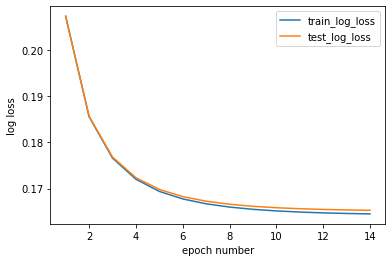

In [ ]:
from matplotlib import pyplot as plt
plt.plot(range(1,epoch+1),trainloss, label='train_log_loss')
plt.plot(range(1,epoch+1),testloss, label='test_log_loss')
plt.xlabel("epoch number")
plt.ylabel("log loss")
plt.legend()
plt.show


In [ ]:
def pred(w,b, X):
    N = len(X)
    predict = []
    for i in range(N):
        z=np.dot(w,X[i])+b
        if sigmoid(z) >= 0.5: # sigmoid(w,x,b) returns 1/(1+exp(-(dot(x,w)+b)))
            predict.append(1)
        else:
            predict.append(0)
    return np.array(predict)
print(1-np.sum(y_train - pred(w,b,X_train))/len(X_train))
print(1-np.sum(y_test  - pred(w,b,X_test))/len(X_test))

0.9505866666666667
0.9476
